# Credit Card Fraud Detection Using ANN

## Objective
Classify credit card transactions as fraudulent (1) or legitimate (0) using an Artificial Neural Network (ANN).

- Target Column: `Class` (0 = Legitimate, 1 = Fraud)
- Model: Artificial Neural Network (Binary Classification)

## 1. Import Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

## 2. Load Dataset and Basic EDA

In [9]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("quant101/cc-fraud-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cc-fraud-dataset' dataset.
Path to dataset files: /kaggle/input/cc-fraud-dataset


In [10]:
import os
# Find the csv file in the downloaded path
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)

df = pd.read_csv(full_path)
display(df.head())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [12]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## 3. Missing Values, Duplicates, and Class Distribution

In [13]:
print("Missing values:", df.isnull().sum().max())
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

Missing values: 0
Duplicates: 1081


In [14]:
print("Class Distribution:")
print(df['Class'].value_counts())
print("\nPercentage:")
print(df['Class'].value_counts(normalize=True) * 100)

Class Distribution:
Class
0    283253
1       473
Name: count, dtype: int64

Percentage:
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


## 4. Feature Selection, Train-Test Split, and Scaling

In [15]:
X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 5. Handling Class Imbalance with SMOTE

In [16]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Class distribution after SMOTE:")
print(pd.Series(y_train_res).value_counts())

Class distribution after SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


## 6. ANN Models Training

### Model 1: ReLU + Adam (20 Epochs)

In [17]:
model1 = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history1 = model1.fit(X_train_res, y_train_res, validation_split=0.2, epochs=20, batch_size=512)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
709/709 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9663 - loss: 0.0864 - val_accuracy: 0.9947 - val_loss: 0.0318
Epoch 2/20
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9973 - loss: 0.0133 - val_accuracy: 0.9999 - val_loss: 0.0093
Epoch 3/20
709/709 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9987 - loss: 0.0062 - val_accuracy: 1.0000 - val_loss: 0.0047
Epoch 4/20
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9992 - loss: 0.0041 - val_accuracy: 0.9999 - val_loss: 0.0026
Epoch 5/20
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9994 - loss: 0.0030 - val_accuracy: 1.0000 - val_loss: 0.0025
Epoch 6/20
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9994 - loss: 0.0025 - val_accuracy: 1.0000 - val_loss: 7.6458e-04
Epoch 7/20
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9996 - loss: 0.0019 - val_accuracy: 1.0000 - val_loss: 5.4741e-04
Epoch 8/20
709/709 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9997 - loss: 0.0016 - val_accu

### Model 2: Tanh + SGD (20 Epochs)

In [18]:
model2 = Sequential([
    Dense(64, activation='tanh', input_shape=(X_train_res.shape[1],)),
    Dense(32, activation='tanh'),
    Dense(1, activation='sigmoid')
])

model2.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
history2 = model2.fit(X_train_res, y_train_res, validation_split=0.2, epochs=20, batch_size=512)

Epoch 1/20
709/709 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9275 - loss: 0.2120 - val_accuracy: 0.8997 - val_loss: 0.1775
Epoch 2/20
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9532 - loss: 0.1208 - val_accuracy: 0.9070 - val_loss: 0.1676
Epoch 3/20
709/709 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9566 - loss: 0.1091 - val_accuracy: 0.9177 - val_loss: 0.1569
Epoch 4/20
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9598 - loss: 0.1028 - val_accuracy: 0.9243 - val_loss: 0.1500
Epoch 5/20
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9615 - loss: 0.0981 - val_accuracy: 0.9266 - val_loss: 0.1456
Epoch 6/20
709/709 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9628 - loss: 0.0940 - val_accuracy: 0.9305 - val_loss: 0.1384
Epoch 7/20
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9641 - loss: 0.0902 - val_accuracy: 0.9330 - val_loss: 0.1328
Epoch 8/20
709/709 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9653 - loss: 0.0867 - val_accuracy: 0.

### Model 3: ReLU + RMSprop (20 Epochs)

In [19]:
model3 = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model3.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
history3 = model3.fit(X_train_res, y_train_res, validation_split=0.2, epochs=20, batch_size=512)

Epoch 1/20
709/709 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9783 - loss: 0.0598 - val_accuracy: 1.0000 - val_loss: 0.0100
Epoch 2/20
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9985 - loss: 0.0075 - val_accuracy: 1.0000 - val_loss: 0.0022
Epoch 3/20
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9991 - loss: 0.0040 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 4/20
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9994 - loss: 0.0029 - val_accuracy: 1.0000 - val_loss: 7.3419e-04
Epoch 5/20
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9995 - loss: 0.0025 - val_accuracy: 0.9997 - val_loss: 0.0027
Epoch 6/20
709/709 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9996 - loss: 0.0020 - val_accuracy: 1.0000 - val_loss: 6.4635e-04
Epoch 7/20
709/709 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9996 - loss: 0.0019 - val_accuracy: 1.0000 - val_loss: 3.6269e-04
Epoch 8/20
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9996 - loss: 0.0017 - val_

## 7. Training Accuracy Comparison

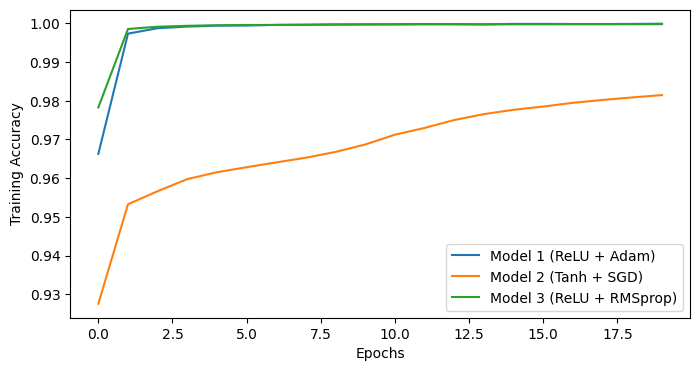

In [20]:
plt.figure(figsize=(8, 4))
plt.plot(history1.history['accuracy'], label='Model 1 (ReLU + Adam)')
plt.plot(history2.history['accuracy'], label='Model 2 (Tanh + SGD)')
plt.plot(history3.history['accuracy'], label='Model 3 (ReLU + RMSprop)')
plt.xlabel('Epochs')
plt.ylabel('Training Accuracy')
plt.legend()
plt.show()

## 8. Model Evaluation and Comparison Table

In [21]:
pred1_prob = model1.predict(X_test, verbose=0)
pred2_prob = model2.predict(X_test, verbose=0)
pred3_prob = model3.predict(X_test, verbose=0)

pred1 = (pred1_prob >= 0.5).astype(int).flatten()
pred2 = (pred2_prob >= 0.5).astype(int).flatten()
pred3 = (pred3_prob >= 0.5).astype(int).flatten()

results = pd.DataFrame({
    'Model': ['Model 1', 'Model 2', 'Model 3'],
    'Activation': ['ReLU', 'Tanh', 'ReLU'],
    'Optimizer': ['Adam', 'SGD', 'RMSprop'],
    'Epochs': [20, 20, 20],
    'Accuracy': [accuracy_score(y_test, pred1), accuracy_score(y_test, pred2), accuracy_score(y_test, pred3)],
    'Precision': [precision_score(y_test, pred1), precision_score(y_test, pred2), precision_score(y_test, pred3)],
    'Recall': [recall_score(y_test, pred1), recall_score(y_test, pred2), recall_score(y_test, pred3)],
    'F1': [f1_score(y_test, pred1), f1_score(y_test, pred2), f1_score(y_test, pred3)]
})

results

,Model,Activation,Optimizer,Epochs,Accuracy,Precision,Recall,F1
0,Model 1,ReLU,Adam,20,0.999207,0.784091,0.726316,0.754098
1,Model 2,Tanh,SGD,20,0.989074,0.117904,0.852632,0.207161
2,Model 3,ReLU,RMSprop,20,0.999242,0.788889,0.747368,0.767568


## 9. Confusion Matrix for Best Model

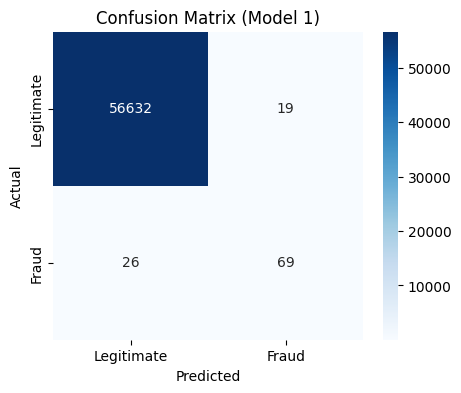

In [22]:
cm = confusion_matrix(y_test, pred1)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Model 1)')
plt.show()

## 10. Sample Predictions

In [23]:
sample_df = pd.DataFrame({
    'Actual Class': y_test.values[:10],
    'Predicted Class': pred1[:10]
})

sample_df['Actual Label'] = sample_df['Actual Class'].map({0: 'Legitimate', 1: 'Fraud'})
sample_df['Predicted Label'] = sample_df['Predicted Class'].map({0: 'Legitimate', 1: 'Fraud'})
sample_df

,Actual Class,Predicted Class,Actual Label,Predicted Label
0,0,0,Legitimate,Legitimate
1,0,0,Legitimate,Legitimate
2,0,0,Legitimate,Legitimate
3,0,0,Legitimate,Legitimate
4,0,0,Legitimate,Legitimate
5,0,0,Legitimate,Legitimate
6,0,0,Legitimate,Legitimate
7,0,0,Legitimate,Legitimate
8,0,0,Legitimate,Legitimate
9,0,0,Legitimate,Legitimate


## 11. Conclusion
Model 1 (ReLU + Adam) achieved the best overall performance:
- In fraud detection, Recall is the most critical metric because missing a fraud transaction (False Negative) is much more costly than a false alarm.
- Applying SMOTE to the training set effectively resolved class imbalance without distorting the real-world test distribution.
- Adam combined with ReLU achieved higher Recall and F1-score than SGD and RMSprop.